In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import spikeinterface.extractors as se
import pandas as pd
import os
import json
from scipy.ndimage import gaussian_filter1d

c:\Users\admaberlenc.a\miniconda3\envs\ephy_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# PATHS

base_folder = Path(r"F:\Data_Mice\VF071_2025_12_18")
shift_path   = base_folder / "shift.txt"
rec_folder   = base_folder / "Rec"
output_folder = base_folder / "Output"
ks_folder    = base_folder / "KS"
alf_folder   = base_folder / "alf"
db_path      = Path(r"F:\Data_Mice\full_db_all_rigs.feather")

In [4]:
# ==========================================================
# === 2) EXTRACTION AUTO MOUSE & DATE DEPUIS LE DOSSIER ====
# ==========================================================
from pathlib import Path
import numpy as np
import pandas as pd
import spikeinterface.extractors as se
from scipy.signal import correlate
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

base_folder = Path(base_folder)
folder_name = base_folder.name                # ex : "VF3970_2025_05_20"
parts = folder_name.split("_")

mouse_id = parts[0]                           # "VF3970"

# ✅ Format réel : YYYY_MM_DD
yyyy = parts[1]   # 2025
mm   = parts[2]   # 05
dd   = parts[3]   # 20

date_str = f"{yyyy}-{mm}-{dd}"

print("✅ Mouse ID :", mouse_id)
print("✅ Date     :", date_str)

# ==========================================================
# ================= 3) CHARGER BEHAVIOR DB =================
# ==========================================================

df = pd.read_feather(db_path)

row = df[(df["Mouse_ID"] == mouse_id) & (df["Date"] == date_str)]

if len(row) == 0:
    raise ValueError(f"❌ Aucun enregistrement behavior pour {mouse_id} / {date_str}")

row = row.iloc[0]
starts = np.asarray(row["Bout Start Times"], dtype=float)

print(f"✅ {len(starts)} bouts behavior trouvés.")

# ==========================================================
# ==================== 4) CHARGER EPHYS ====================
# ==========================================================

print("📥 Chargement LF + sync...")
rec_lf = se.read_spikeglx(str(rec_folder), stream_id="imec0.lf", load_sync_channel=True)

fs = rec_lf.get_sampling_frequency()
sync = rec_lf.get_traces(start_frame=0, end_frame=rec_lf.get_num_frames())[:, -1]

n = len(sync)
print(f"✅ LF Fs = {fs:.1f} Hz | durée = {n/fs/60:.1f} min")

# ==========================================================
# =================== 5) DÉTECTION TTL =====================
# ==========================================================

binary = (sync > 32).astype(np.uint8)

win_s           = 1
min_ones_in_win = 2
min_silence_s   = 1
hold_low_s      = 1

win_n  = int(win_s * fs)
kernel = np.ones(win_n, dtype=np.int32)
count  = np.convolve(binary, kernel, mode="same")
active = (count >= min_ones_in_win).astype(np.uint8)

one_idx = np.flatnonzero(binary)
rise_times = []

min_silence_n = int(min_silence_s * fs)
hold_low_n    = int(hold_low_s    * fs)

state = "inactive"
last_end_idx = -999999

i = 1
while i < n:
    if state == "inactive":
        if active[i-1] == 0 and active[i] == 1 and (i - last_end_idx) >= min_silence_n:
            jpos = np.searchsorted(one_idx, i)
            if jpos < len(one_idx):
                first_one = one_idx[jpos]
                rise_times.append(first_one / fs)
                state = "active"
                i = max(i+1, first_one+1)
                continue
    else:
        if active[i] == 0:
            low_run = 1
            k = i+1
            while k < n and active[k] == 0 and low_run < hold_low_n:
                low_run += 1
                k += 1
            if low_run >= hold_low_n:
                last_end_idx = k
                state = "inactive"
                i = k
                continue
    i += 1

ts_events = np.array(rise_times)
print(f"✅ {len(ts_events)} événements ephys détectés.")

# ==========================================================
# ======== 6) ALIGNEMENT GROSSIER PAR CROSS-CORR ===========
# ==========================================================

bin_size = 0.1
tmax = int(max(starts[-1], ts_events[-1]) // bin_size) + 1

v_beh = np.zeros(tmax)
v_eph = np.zeros(tmax)
v_beh[(starts/bin_size).astype(int)] = 1
v_eph[(ts_events/bin_size).astype(int)] = 1

xcorr = correlate(v_beh, v_eph, mode="full")
lags = np.arange(-len(v_eph)+1, len(v_beh))
best_lag = lags[np.argmax(xcorr)] * bin_size

print(f"✅ Décalage global estimé : {best_lag:.2f} s")

ts_events_shifted = ts_events + best_lag

# ==========================================================
# ========== 7) ALIGNEMENT FIN PAR RÉGRESSION ==============
# ==========================================================

paired_x = []
paired_y = []

for y in starts:
    diffs = np.abs(ts_events_shifted - y)
    idx   = np.argmin(diffs)
    if diffs[idx] < 5:
        paired_x.append(ts_events[idx])
        paired_y.append(y)

paired_x = np.array(paired_x)
paired_y = np.array(paired_y)

reg = LinearRegression().fit(paired_x.reshape(-1,1), paired_y)
a, b = reg.coef_[0], reg.intercept_

print(f"✅ Alignement fin : t_behavior = {a:.6f} * t_ephys + {b:.6f}")

# ==========================================================
# ==================== 8) FIGURES ==========================
# ==========================================================

plt.figure(figsize=(9,5))
plt.scatter(paired_x, paired_y, label="Correspondances")
plt.plot(paired_x, reg.predict(paired_x.reshape(-1,1)),
         label=f"y = {a:.3f}x + {b:.3f}")
plt.xlabel("Ephys"); plt.ylabel("Behavior")
plt.title("Fine Regression")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(starts, np.ones_like(starts)*1.0, "|", markersize=15, label="Behavior")
plt.plot(ts_events, np.ones_like(ts_events)*0.9, "|", markersize=15, label="Ephys raw")
plt.plot(a*ts_events + b, np.ones_like(ts_events)*0.8, "|", markersize=15, label="Ephys shifted")
plt.legend(); plt.grid(True)
plt.title("Alignment")
plt.tight_layout()
plt.show()

# ==========================================================
# === 7B) SAUVEGARDE DU DÉCALLAGE b DANS BASE_FOLDER =======
# ==========================================================

shift_path = base_folder / "shift.txt"

with open(shift_path, "w") as f:
    f.write(f"{b:.6f}\n")

print(f"💾 Décalage (b) sauvegardé dans : {shift_path}")



✅ Mouse ID : VF071
✅ Date     : 2025-12-18


ValueError: ❌ Aucun enregistrement behavior pour VF071 / 2025-12-18

In [3]:
# ==========================================================
# === PATHS ================================================
# ==========================================================

shift_path  = base_folder / "shift.txt"


# ==========================================================
# === 1) SHIFT ==============================================
# ==========================================================

shift = float(Path(shift_path).read_text().strip())
print("✅ Décalage chargé :", shift, "s")


# ==========================================================
# === 2) LECTURE KS + RECORDING =============================
# ==========================================================

sorting = se.read_kilosort(ks_folder)
recording = se.read_spikeglx(rec_folder, stream_id="imec0.ap")

fs = recording.get_sampling_frequency()
print("✅ Sorting + recording chargés. Fs =", fs)


# ==========================================================
# === 3) RECONSTRUIRE TOUS LES SPIKES =======================
# ==========================================================

unit_ids = sorting.get_unit_ids()

all_times_ephys = []
all_units = []

for uid in unit_ids:
    st = sorting.get_unit_spike_train(uid)
    all_times_ephys.append(st)
    all_units.append(np.full(len(st), uid, dtype=int))

all_times_ephys = np.concatenate(all_times_ephys)
all_units       = np.concatenate(all_units)

order = np.argsort(all_times_ephys)
all_times_ephys = all_times_ephys[order]
all_units       = all_units[order]

print("✅ Spikes reconstruits :", len(all_times_ephys))


# ==========================================================
# === 4) CONVERSION EPHYS → BEHAVIOR ========================
# ==========================================================

spike_times_beh = all_times_ephys / fs + shift
print("✅ Conversion ephys → behavior OK.")


# ==========================================================
# === 5) CHARGER spike_positions.npy (channel KS) ===========
# ==========================================================

pos = np.load(ks_folder / "spike_positions.npy")
spike_channels = pos[:, 1].astype(int)


# ==========================================================
# === 6) CHARGER LES LICKS SEULEMENT ========================
# ==========================================================

folder_name = base_folder.name
parts = folder_name.split("_")

mouse_id = parts[0]
yyyy, mm, dd = parts[1], parts[2], parts[3]
date_str = f"{yyyy}-{mm}-{dd}"

df = pd.read_feather(db_path)
row = df[(df["Mouse_ID"] == mouse_id) & (df["Date"] == date_str)].iloc[0]

def flatten_array_of_arrays(arr):
    out = []
    for x in arr:
        if isinstance(x, (list, np.ndarray)):
            out.extend(list(x))
    return np.array(out, dtype=float)

lick_rewarded    = flatten_array_of_arrays(row["Times Rewarded Licks"])
lick_nonrewarded = flatten_array_of_arrays(row["Times Non Rewarded Licks"])
lick_invalid     = flatten_array_of_arrays(row["Times Invalid Licks"])

print("✅ Rewarded licks :", len(lick_rewarded))
print("✅ Nonrewarded licks :", len(lick_nonrewarded))
print("✅ Invalid licks :", len(lick_invalid))


# ==========================================================
# === 7) RASTER : SPIKES + LICKS ============================
# ==========================================================

plt.figure(figsize=(18, 10))

# ----- Spikes (noir) -----
plt.vlines(spike_times_beh,
           spike_channels,
           spike_channels + 0.9,
           color="black",
           linewidth=0.2,
           alpha=0.7)

# ----- Rewarded licks (vert) -----
for t in lick_rewarded:
    plt.axvline(t, color="green", linewidth=0.5, alpha=0.9)

# ----- Non-rewarded licks (rouge) -----
for t in lick_nonrewarded:
    plt.axvline(t, color="red", linewidth=0.5, alpha=0.9)

# ----- Invalid licks (gris clair) -----
for t in lick_invalid:
    plt.axvline(t, color="gray", linewidth=0.3, alpha=0.5)

plt.xlabel("Temps (s) – behavior time reference")
plt.ylabel("Channels")
plt.title("Spikes :  Rewarded licks = green , Nonrewarded licks = red , Invalid liks = gray")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'F:\\Data_Mice\\VF071_2025_12_18\\shift.txt'

✅ Décalage chargé : 29.242512 s
✅ Spikes: 6649028 | Profondeur y min–max: 31.6 → 3825.5
✅ Clusters good : 320
✅ Régions assignées aux spikes : 6649028
✅ Bouts: 23
✅ Bouts sélectionnés : [ 150.868    2712.532992 3979.705984 4917.004    4954.708992]
🔧 Calcul FR global et Z-score…
✅ OK.


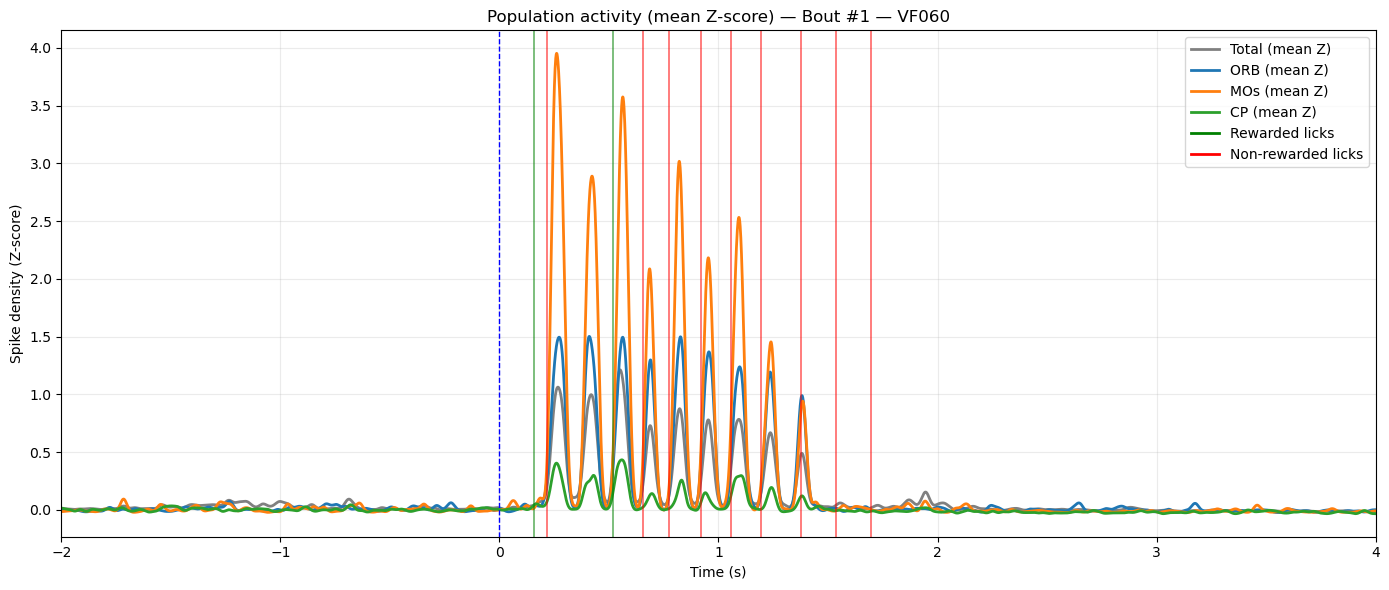

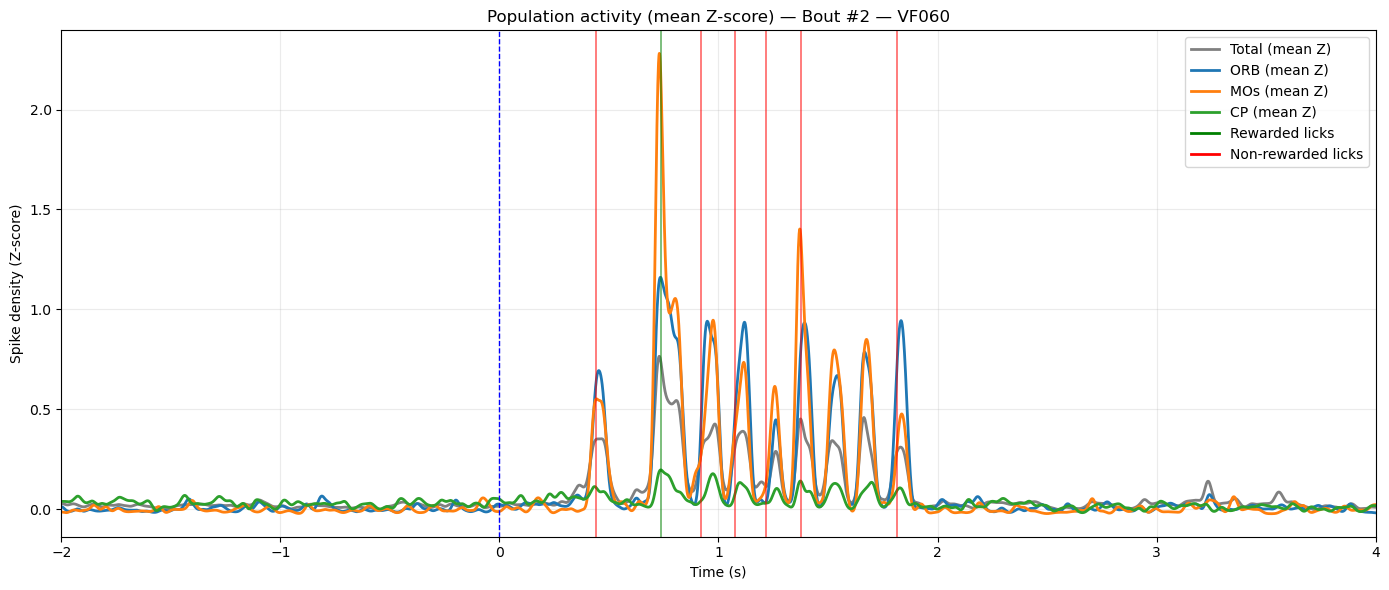

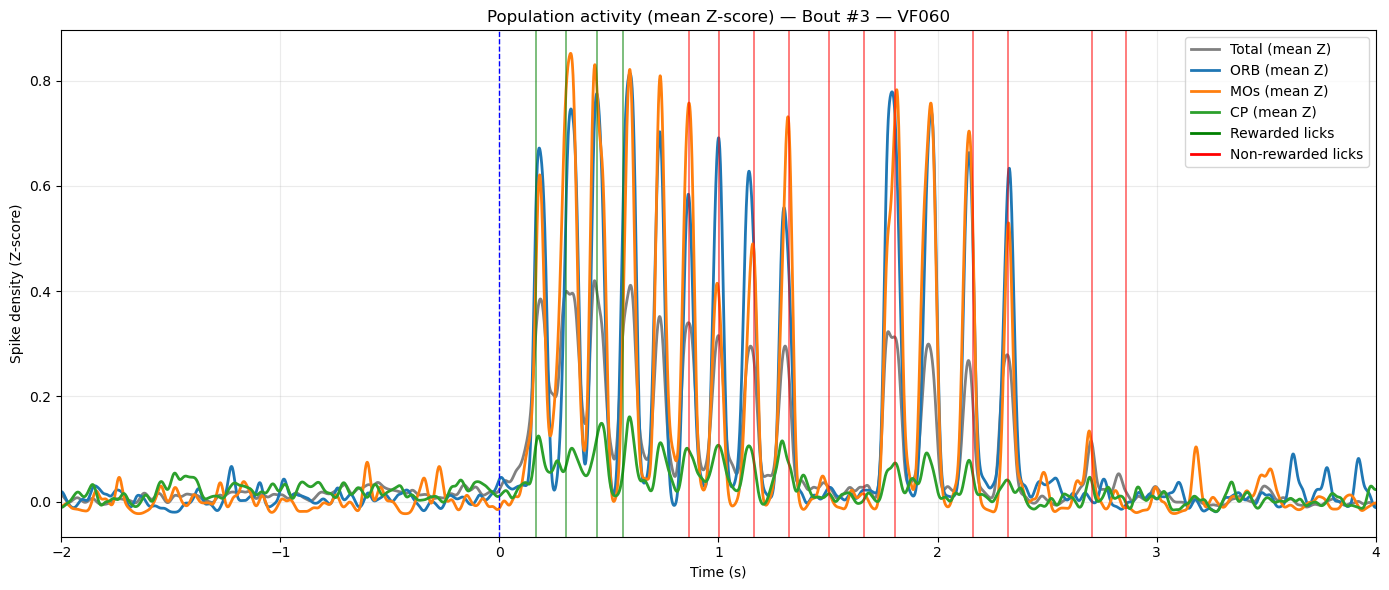

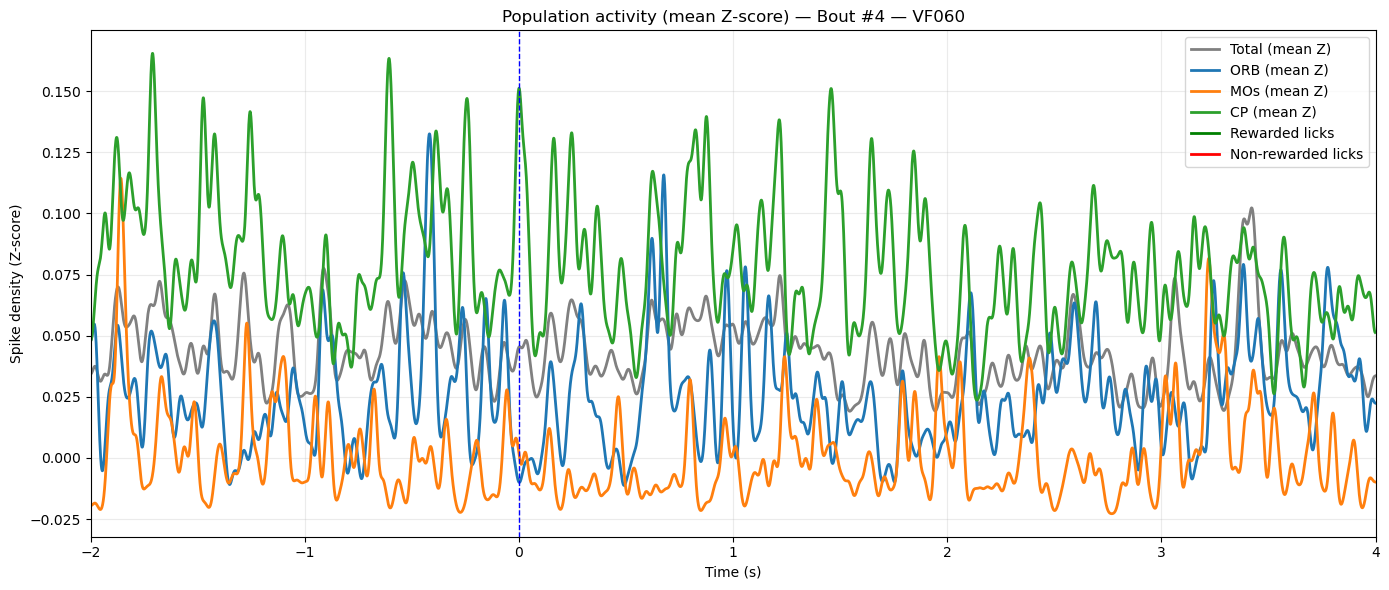

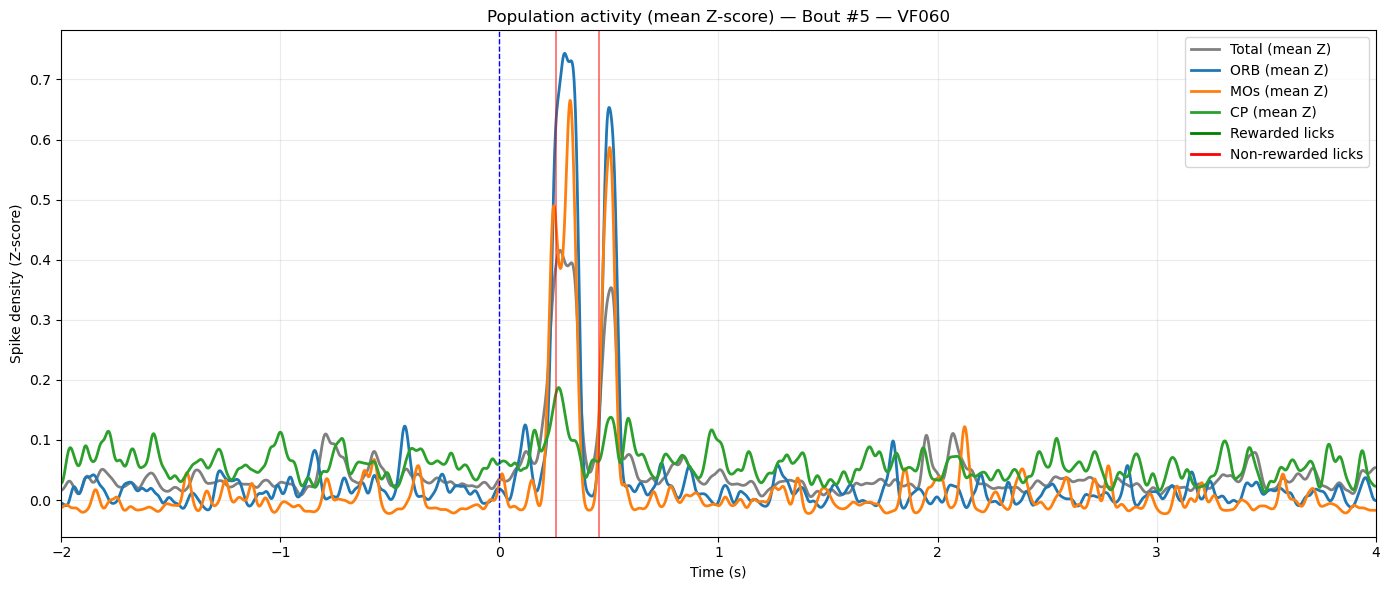

In [8]:
# ==========================================================
# === PARAMÈTRES ==========================================
# ==========================================================

window_before = 2
window_after  = 4
bin_size = 0.001
sigma_s  = 0.015
N_BOUTS = 5
target_regions = ["ORB", "MOs", "CP"]
use_good_only = True

# Colonnes minimales à charger depuis le Feather
needed_cols = [
    "Mouse_ID",
    "Date",
    "Bout Start Times",
    "Times Rewarded Licks",
    "Times Non Rewarded Licks",
]

# ==========================================================
# === 1) SHIFT =============================================
# ==========================================================

shift = float(Path(shift_path).read_text().strip())
print("✅ Décalage chargé :", shift, "s")

# ==========================================================
# === 2) SPIKES & CLUSTERS KS ==============================
# ==========================================================

sorting = se.read_kilosort(ks_folder)
fs = sorting.get_sampling_frequency()

spike_times = np.load(ks_folder / "spike_times.npy") / fs
spike_clusters = np.load(ks_folder / "spike_clusters.npy")
spike_positions = np.load(ks_folder / "spike_positions.npy")
depths = spike_positions[:, 1]
spike_times_beh = spike_times + shift

print(f"✅ Spikes: {len(spike_times)} | Profondeur y min–max: {depths.min():.1f} → {depths.max():.1f}")

# --- Filtrage "good"
good_clusters = None
tsv_path = alf_folder / "cluster_KSLabel.tsv"
if use_good_only and tsv_path.exists():
    df_lab = pd.read_csv(tsv_path, sep="\t")
    if "KSLabel" in df_lab.columns:
        good_clusters = set(df_lab.loc[df_lab["KSLabel"].str.lower()=="good", "cluster_id"].astype(int))
    elif "label" in df_lab.columns:
        good_clusters = set(df_lab.loc[df_lab["label"].str.lower()=="good", "cluster_id"].astype(int))
    print("✅ Clusters good :", len(good_clusters))
else:
    print("ℹ️ Pas de filtrage good.")

# ==========================================================
# === 3) CHANNEL LOCATIONS ================================
# ==========================================================

with open(alf_folder / "channel_locations.json", "r") as f:
    data = json.load(f)

df_channels = pd.DataFrame.from_dict(data, orient="index").reset_index()
df_channels["channel_id"] = df_channels["index"].astype(str).str.extract(r"(\d+)").astype(float)
df_channels = df_channels.dropna(subset=["channel_id"])
df_channels["channel_id"] = df_channels["channel_id"].astype(int)
df_channels = df_channels.sort_values("axial").reset_index(drop=True)

def simplify_region(name):
    if pd.isna(name):
        return "other"
    n = name.upper()
    if "ORB" in n:
        return "ORB"
    if "MO" in n or "MOS" in n:
        return "MOs"
    if "CP" in n:
        return "CP"
    return "other"

df_channels["region_simplified"] = df_channels["brain_region"].apply(simplify_region)

axial_edges = df_channels["axial"].values
region_lookup = df_channels["region_simplified"].values

def region_from_depth(d):
    idx = np.argmin(np.abs(axial_edges - d))
    return region_lookup[idx]

spike_regions = np.array([region_from_depth(d) for d in depths])
print("✅ Régions assignées aux spikes :", len(spike_regions))

# ==========================================================
# === 4) BOUTS & LICKS =====================================
# ==========================================================

folder_name = base_folder.name
parts = folder_name.split("_")
mouse_id = parts[0]
yyyy, mm, dd = parts[1], parts[2], parts[3]
date_str = f"{yyyy}-{mm}-{dd}"

# 🔥 LECTURE FEATHER OPTIMISÉE (évite ArrowMemoryError)
df = pd.read_feather(db_path, columns=needed_cols)

row = df[(df["Mouse_ID"]==mouse_id) & (df["Date"]==date_str)].iloc[0]

starts = np.asarray(row["Bout Start Times"], dtype=float)

def flatten(arr):
    out = []
    for x in arr:
        if isinstance(x,(list,np.ndarray)):
            out.extend(list(x))
    return np.array(out, dtype=float)

lick_rewarded = flatten(row["Times Rewarded Licks"])
lick_nonrewarded = flatten(row["Times Non Rewarded Licks"])

print("✅ Bouts:", len(starts))

# ==========================================================
# === 5) RÉGION PAR CLUSTER ================================
# ==========================================================

clusters = np.unique(spike_clusters)
if good_clusters is not None:
    clusters = np.array([c for c in clusters if c in good_clusters])

cluster_region = {}
for c in clusters:
    idx = (spike_clusters == c)
    if not np.any(idx):
        continue
    med_d = np.median(depths[idx])
    cluster_region[c] = region_from_depth(med_d)

# ==========================================================
# === 6) SÉLECTION DES BOUTS ===============================
# ==========================================================

Tmin, Tmax = spike_times_beh.min(), spike_times_beh.max()
valid_bouts = [b for b in np.sort(starts) if (b - window_before >= Tmin) and (b + window_after <= Tmax)]
valid_bouts = np.random.choice(valid_bouts, size=min(N_BOUTS,len(valid_bouts)), replace=False)
valid_bouts = np.sort(valid_bouts)
print("✅ Bouts sélectionnés :", valid_bouts)

# ==========================================================
# === 7) FIRING RATE GLOBAL + Z-SCORE ======================
# ==========================================================

print("🔧 Calcul FR global et Z-score…")

t_min, t_max = spike_times_beh.min(), spike_times_beh.max()
edges_global = np.arange(t_min, t_max, bin_size)

unit_ids = np.unique(spike_clusters)
FR_global = {}
meanFR = {}
stdFR = {}

for uid in unit_ids:
    st = spike_times_beh[spike_clusters == uid]
    counts, _ = np.histogram(st, bins=edges_global)
    fr = counts / bin_size
    FR_global[uid] = fr
    meanFR[uid] = fr.mean()
    stdFR[uid] = fr.std() if fr.std()>0 else 1e-6

print("✅ OK.")

# ==========================================================
# === 8) PLOTS Z-SCORE ====================================
# ==========================================================

def plot_licks(licks, color):
    mask = (licks >= t0) & (licks <= t1)
    for t in licks[mask]:
        plt.axvline(t - bout, color=color, alpha=0.6, linewidth=1.2)

for i, bout in enumerate(valid_bouts):

    t0, t1 = bout - window_before, bout + window_after
    edges = np.arange(t0, t1, bin_size)
    t_rel = edges - bout

    plt.figure(figsize=(14,6))

    # --- Z-score population ---
    Z_total = np.zeros(len(edges)-1)
    for uid in unit_ids:
        st = spike_times_beh[spike_clusters == uid]
        st = st[(st >= t0) & (st <= t1)]
        counts, _ = np.histogram(st, bins=edges)
        fr = counts / bin_size
        z = (fr - meanFR[uid]) / stdFR[uid]
        Z_total += z / len(unit_ids)

    Z_total_s = gaussian_filter1d(Z_total, sigma=sigma_s/bin_size)

    plt.plot(t_rel[:-1], Z_total_s, color="gray", linewidth=2, label="Total (mean Z)")

    # --- Z-score par région ---
    for region in target_regions:
        region_clusters = [c for c,r in cluster_region.items() if r == region]
        if len(region_clusters)==0:
            continue

        Z_reg = np.zeros(len(edges)-1)
        for uid in region_clusters:
            st = spike_times_beh[spike_clusters == uid]
            st = st[(st >= t0) & (st <= t1)]
            counts, _ = np.histogram(st, bins=edges)
            fr = counts / bin_size
            z = (fr - meanFR[uid]) / stdFR[uid]
            Z_reg += z / len(region_clusters)

        Z_reg_s = gaussian_filter1d(Z_reg, sigma=sigma_s/bin_size)
        plt.plot(t_rel[:-1], Z_reg_s, linewidth=2, label=f"{region} (mean Z)")

    # --- Licks ---
    plot_licks(lick_rewarded, "green")
    plot_licks(lick_nonrewarded, "red")

    plt.plot([], [], color="green", linewidth=2, label="Rewarded licks")
    plt.plot([], [], color="red", linewidth=2, label="Non-rewarded licks")

    plt.axvline(0, color="blue", linestyle="--", linewidth=1)
    plt.xlim(-window_before, window_after)
    plt.xlabel("Time (s)")
    plt.ylabel("Spike density (Z-score)")
    plt.title(f"Population activity (mean Z-score) — Bout #{i+1} — {mouse_id}")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
